In [2]:
import seaborn
import matplotlib.pyplot as plt
import numpy as np
import scipy
import random
import statistics

# Exercise 1

In [25]:
NUM_SAMPLES = 10_000

def LCG_sample(x:int, a: int, c: int, M: int):
    return int((a*x + c) % M)

def sample_numbers(num: int = NUM_SAMPLES, a: int = 23, c: int = 1, M: int = 1e8 + 1, seed: int = 5_000, uniform: bool = True) -> list[int] | list[float]:
    samples = [seed/M if uniform else seed]
    x = seed
    for _ in range(num):
        x = LCG_sample(x, a, c, M)
        samples.append(x/M if uniform else x)
    return samples

def cycle_length(samples: list[int] | list[float]) -> int:
    first = samples[0]
    try:
        repeated_first = samples[1:].index(first)
    except ValueError:
        return len(samples)
    return repeated_first + 1

def plot_samples(samples: list[int] | list[float], save_fig: bool = False, filename: str = "lcg_samples.png"):
    # left = histogram, right = scatterplot of i vs i+1
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    seaborn.histplot(samples, bins=10, ax=ax1)
    ax1.set_title("Histogram of samples")
    ax1.set_xlabel("Value")
    ax1.set_ylabel("Frequency")

    # Scatter with small dots
    ax2.scatter(samples[:-1], samples[1:], alpha=0.5, s=10)
    ax2.set_title("Scatterplot of i vs i+1")
    ax2.set_xlabel("Sample i")
    ax2.set_ylabel("Sample i+1")

    # Big title
    plt.suptitle(f"LCG Samples (Cycle of length {cycle_length(samples)})", fontsize=16)
    if save_fig:
        plt.savefig(filename)
    plt.show()


def chi_square_test(samples: list[int] | list[float], num_bins: int = 10) -> float:
    # First we get the test statistic based on the observed counts versus the expected number.
    # Expected is the same for each bin, as we want to assume an underlying uniform distribution.
    observed_counts, _ = np.histogram(samples, bins=num_bins, range=(0, 1))  # Setting range, to make sure we get the interval of between 0 and 1, even if samples are not; also two less degrees of freedom :)
    expected_count = len(samples) / num_bins
    chi_square_statistic = np.sum((observed_counts - expected_count) ** 2 / expected_count)
    
    # Uniform has no parameters to estiamte, so df = num_bins - 1
    degrees_of_freedom = num_bins - 1

    # We can get the p-value from the chi-square distribution scipy.
    p_value = scipy.stats.chi2.sf(chi_square_statistic, df=degrees_of_freedom)
    return p_value

def wald_wolfowitz_test(samples: list[int] | list[float]) -> float:
    median = statistics.median(samples)
    n_pos = sum(1 for x in samples if x > median)
    n_neg = sum(1 for x in samples if x < median)

    sides = [1 if value > median else -1 for value in samples if value != median]

    total_runs = 1
    for previous_side, current_side in zip(sides, sides[1:]):
        if current_side != previous_side:
            total_runs += 1

    expected_runs = (2 * n_pos * n_neg) / (n_pos + n_neg) + 1
    variance_runs = (2 * n_pos * n_neg * (2 * n_pos * n_neg - n_pos - n_neg)) \
                    / ((n_pos + n_neg) ** 2 * (n_pos + n_neg - 1))

    z_score = (total_runs - expected_runs) / np.sqrt(variance_runs)
    p_value = 2 * scipy.stats.norm.sf(abs(z_score))
    
    return p_value

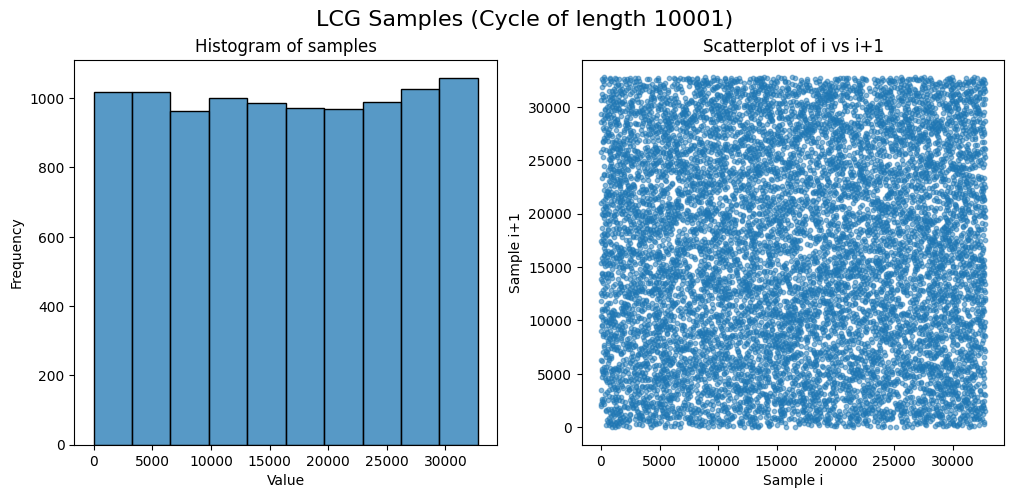

0.0
0.6030454504339671


In [ ]:
a_ = 6969
c_ = 67
M_ = 2**15

# C-style LCG parameters.
C_sample_numbers = sample_numbers(a=a_, c=c_, M=M_, uniform=True)
plot_samples(C_sample_numbers)
print(chi_square_test(C_sample_numbers))
print(wald_wolfowitz_test(C_sample_numbers))

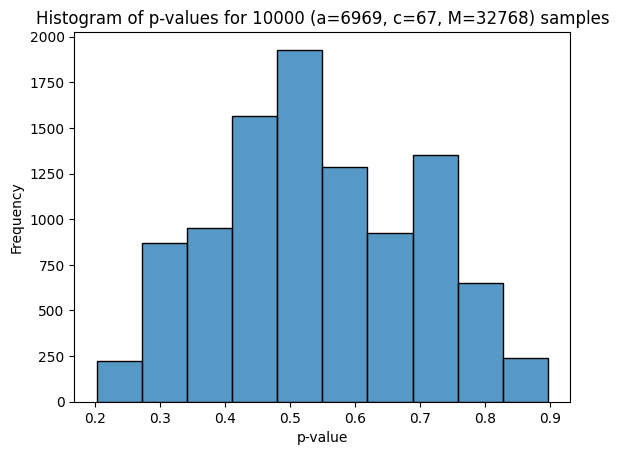

In [24]:
# Check uniformity of P-values for 'C_sample_numbers' setup.
p_values = []
for _ in range(10000):
    samples = sample_numbers(a=a_, c=c_, M=M_, uniform=True, seed=random.randint(0, int(1e8)))
    p_values.append(chi_square_test(samples))
seaborn.histplot(p_values, bins=10)
plt.title(f"Histogram of p-values for 10000 (a={a_}, c={c_}, M={M_}) samples")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

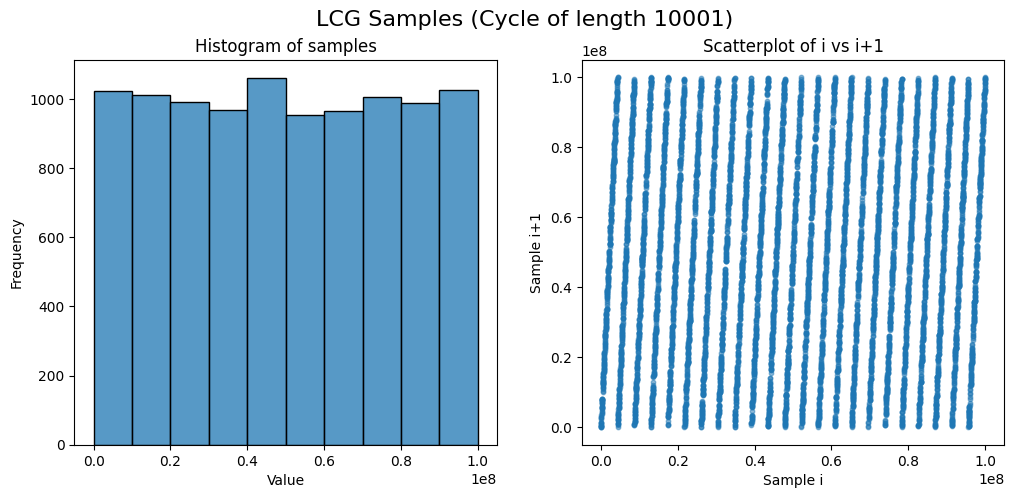

0.3922864084396708


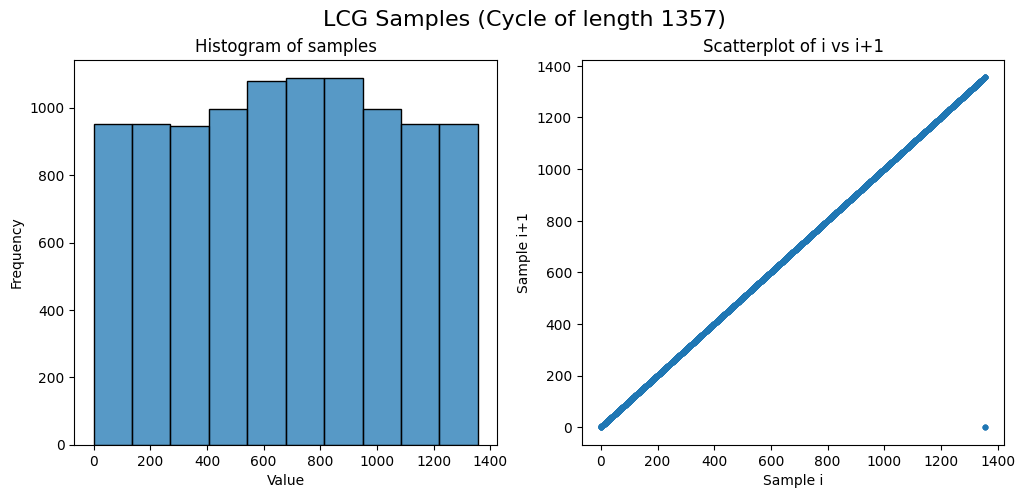

8.375133488736086e-05


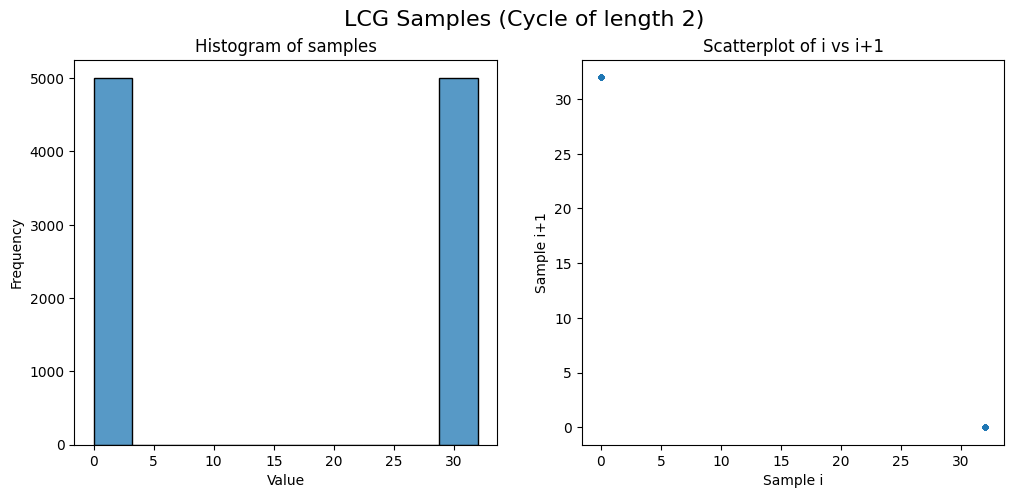

0.0
nan


/tmp/ipykernel_22437/248476234.py:78: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (total_runs - expected_runs) / np.sqrt(variance_runs)


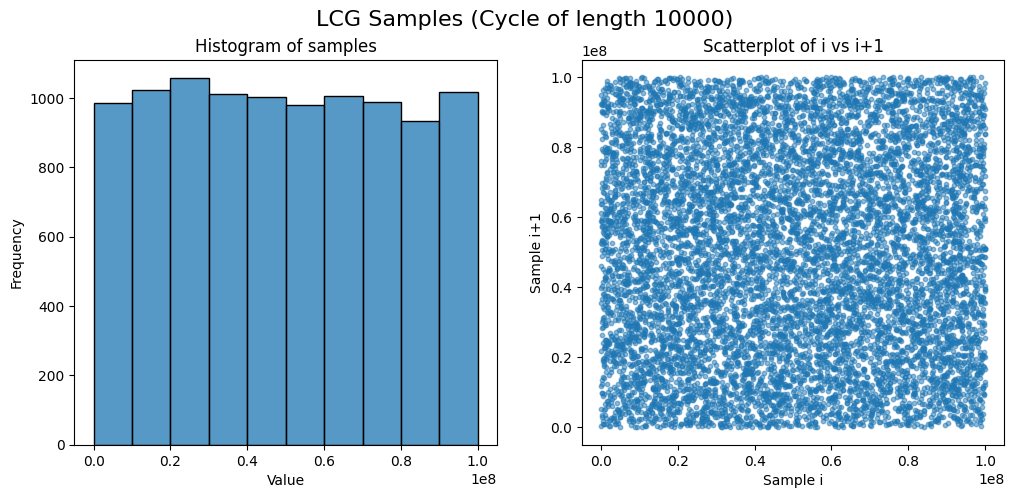

0.3940212153347099


In [6]:
example_sample_numbers = sample_numbers(a=23, c=1, M=1e8+1, uniform=False, seed=500) # with numbers from lecture
plot_samples(example_sample_numbers)
print(chi_square_test(example_sample_numbers))

bad_sample_numbers = sample_numbers(a=1358, M=23*59, uniform=False, seed=500)  # has max cycle length
plot_samples(bad_sample_numbers)
print(chi_square_test(bad_sample_numbers))

really_bad = sample_numbers(a = 1, c=32, M = 64, uniform=False, seed=0)
plot_samples(really_bad)
print(chi_square_test(really_bad))
print(wald_wolfowitz_test(really_bad))

built_in_numbers = [random.randint(0, int(1e8)) for _ in range(10_000)]
plot_samples(built_in_numbers)
print(chi_square_test(built_in_numbers))

0.1305946479503253
0.843619393905709
0.677650600288538
0.884970340922368
0.4856166790190447
0.10950007460055197
0.4788392438241842
0.11860424820040537
0.1747281929580521
0.6075771981998976
0.8192441988051048
0.6144339353678098
0.3625990973080747
0.4116609573292527
0.5538089482308794
0.2645019371060006
0.1720563891946474
0.6113162694867982
0.205093809281093
0.41041167855477
0.29323520206828035
0.24361014648541898
0.1066243289466515
0.9739145993266246
0.9185020283447588
0.22458575743501602
0.574286333205477
0.7322884451209248
0.4095206574549889
0.9098258090383258
0.4945874481321776
0.9999091530295902
0.013875624390268819
0.30826369787625696
0.6275413467078528
0.9218710789673416
0.7421181160399539
0.040186942183377664
0.22224741702637302
0.5247017856198402
0.5189039436963262
0.324128774456617
0.9840343951686954
0.9434489683759548
0.38211454207774315
0.7160857646899861
0.12275273203863118
0.20839363818423795
0.33422421411596054
0.8801447077069633
0.12483714223089108
0.969874531348079
0.748

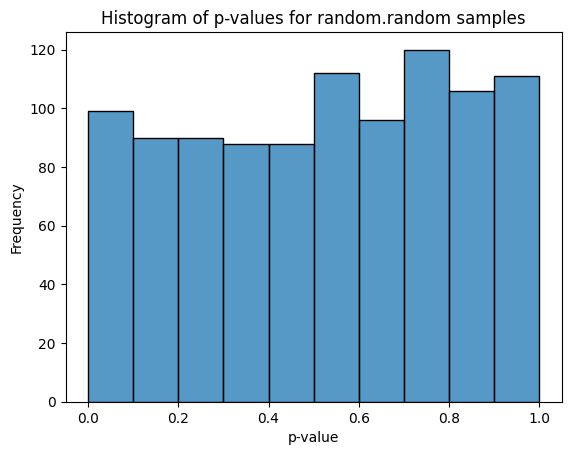

In [20]:
# Check uniformity of P-values for 'C_sample_numbers' setup.
p_values = []
for _ in range(1000):
    samples = [random.random() for _ in range(10_000)]
    p_values.append(chi_square_test(samples))
seaborn.histplot(p_values, bins=10)
plt.title("Histogram of p-values for random.random samples")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()